# Loading

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import importlib
import glaciation_time_estimator.data_postprocessing.Extract_glaciations as eg
import glaciation_time_estimator.data_postprocessing.combine_datasets as cd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
import glaciation_time_estimator.data_postprocessing.Tracking_result_analysis as Tra


In [2]:
config=read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/debug/file_combination_test.yaml")

## Update state

In [41]:
importlib.reload(cd)
importlib.reload(eg)
importlib.reload(Tra)

<module 'glaciation_time_estimator.data_postprocessing.Tracking_result_analysis' from '/net/ch4/wolke_scratch/dnikolo/Glaciation_time_estimator/src/glaciation_time_estimator/data_postprocessing/Tracking_result_analysis.py'>

In [42]:
config=read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/debug/file_combination_test.yaml")

# Postprocessing run

Do postprocessing

In [ ]:
Tra.analyze_tracked_clouds(config)

Analyzing np
Analyzing np 6_0 with 13400 tracks
Analyzing np 12_6 with 13763 tracks
Analyzing np 18_12 with 13937 tracks
Analyzing np 24_18 with 12365 tracks
np - -24 to -18: No cloud timestep: 20090101_181500
np - -6 to 0: No cloud timestep: 20090101_181500
np - -24 to -18: No cloud timestep: 20090101_183000np - -6 to 0: No cloud timestep: 20090101_183000

np - -6 to 0: No cloud timestep: 20090101_184500np - -24 to -18: No cloud timestep: 20090101_184500

np - -24 to -18: No cloud timestep: 20090101_190000
np - -6 to 0: No cloud timestep: 20090101_190000
np - -24 to -18: No cloud timestep: 20090101_191500
np - -6 to 0: No cloud timestep: 20090101_191500
np - -24 to -18: No cloud timestep: 20090101_193000
np - -6 to 0: No cloud timestep: 20090101_193000
np - -24 to -18: No cloud timestep: 20090101_194500
np - -6 to 0: No cloud timestep: 20090101_194500np - -24 to -18: No cloud timestep: 20090101_200000

np - -6 to 0: No cloud timestep: 20090101_200000np - -24 to -18: No cloud timestep:

Combine one year of measurements

In [91]:
if config.get("Analyze_year",True):
    cd.combine_whole_year(config)

Analysing 2009_tracking/01_01.yaml
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/np/20090101.0000_20090115.0000/Agg_03_T_06_00.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/sp/20090101.0000_20090115.0000/Agg_03_T_06_00.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/np/20090101.0000_20090115.0000/Agg_03_T_12_06.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/sp/20090101.0000_20090115.0000/Agg_03_T_12_06.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/np/20090101.0000_20090115.0000/Agg_03_T_18_12.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/sp/20090101.0000_20090115.0000/Agg_03_T_18_12.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/np/20090101.0000_20090115.0000/Agg_03_T_24_18.parquet
fp searched: /net/ch4/wolke_scratch/dnikolo/dump/combination_test/sp/20090101.0000_20090115.0000/Agg_03_T_24_18.parquet
fp se

In [95]:
eg.extract_glaciations_whole_year(config)

Loading combined yearly cloud dataframe
Extracting glaciation events
Error in select_peaks: index -1 is out of bounds for axis 0 with size 0
Data: [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan 6.7952220e-05 0.0000000e+00 1.7783872e-04
 1.4415946e-04 3.9024209e-04 5.0114621e-05 0.0000000e+00 0.0000000e+00
 

AttributeError: 'tuple' object has no attribute 'tb_frame'

# Logical checks

In [17]:
p1 = pd.read_parquet("/wolke_scratch/dnikolo/dump/combination_test/np/20090215.0015_20090215.1500/Agg_03_T_06_00.parquet", )
p2 = pd.read_parquet("/wolke_scratch/dnikolo/dump/combination_test/np/20090215.1500_20090301.0000/Agg_03_T_06_00.parquet")

In [ ]:
def check_if_nan(df):
    df["is_nan"] = df["ice_frac_hist"].apply(lambda x:  (np.count_nonzero(np.isnan(x))>0))


In [10]:
tracked_data = xr.load_dataset("/wolke_scratch/dnikolo/Euler_backup/np/Agg_03_T_06_00/20090101.0000_20090115.0000/pixel_path_tracking/20090101.0000_20090115.0000/cloudtracks_20090101_231500.nc")

In [37]:
orig_cph_data = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2009/01/01/CPPin20090101231500405SVMSG01MD.nc")

In [35]:
import matplotlib.pyplot as plt

In [ ]:
orig_cph_data

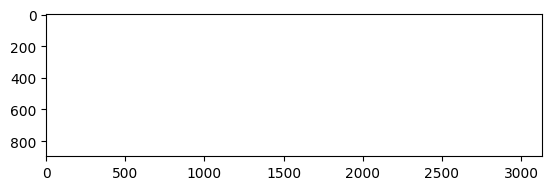

In [38]:
plt.imshow(orig_cph_data.cph[0,:,:])

In [23]:
(tracked_data.cph_filtered==0).all()

<xarray.DataArray 'cph_filtered' ()> Size: 1B
array(True)

In [ ]:
data = xr.open_dataset("")

In [147]:
agg_data_np = xr.load_dataset(config["aux_fps_agg"]["np"])

In [149]:
np.isnan(agg_aux.pixel_area.values[1,:,:]).any()

False

In [116]:
check_if_nan(p1)

In [119]:
p1.is_nan

0      False
1      False
2      False
3       True
4      False
       ...  
683    False
684     True
685     True
686     True
687    False
Name: is_nan, Length: 688, dtype: bool

In [121]:
import xarray as xr

In [141]:
np.isnan(1).any()

False

In [137]:
~np.isnan(agg_aux.pixel_area.values[0,:,:]).any()

True

In [ ]:
agg_aux = xr.load_dataset("/wolke_scratch/dnikolo/dump/agg_aux_files/agg_pixel_area_np.nc")

In [36]:
agg_aux.pixel_area.values[0,287,729]

0.0

In [26]:
aux_norm = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc", decode_times=False)

In [34]:
agg_aux.pixel_area.values[0,np.array([1, 287, 287, 287]).T,np.array([1, 729, 739, 740]).T]

array([  0.      , 111.02514 , 112.361984, 112.50137 ], dtype=float32)

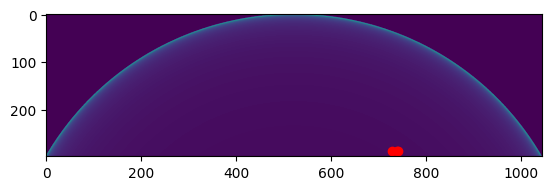

In [28]:
import matplotlib.pyplot as plt
plt.imshow(agg_aux.pixel_area.values[1,:,:])

729, 739, 740
plt.scatter([729, 739, 740],[287, 287, 287], color='red')

In [112]:
df["if_nan"].value_counts(normalize=True)

if_nan
False    0.884805
True     0.115195
Name: proportion, dtype: float64

In [48]:
df =  pd.read_parquet("/wolke_scratch/dnikolo/dump/combination_test/Final_results/2009_all.parquet")

In [76]:
min_start_time = pd.Timestamp(year=2009, month=2, day=15, hour=0)
max_start_time = pd.Timestamp(year=2009, month=2, day=15, hour=14)
min_end_time = pd.Timestamp(year=2009, month=2, day=15, hour=16)


In [77]:
df[(df["track_start_time"]>=min_start_time) & (df["track_start_time"]<=max_start_time) & (df["track_start_time"]+df["track_length"]>=min_end_time)]

,tracknumber,is_large_pix_cloud,is_cot_valid_cloud,is_ctp_valid_cloud,is_liq,is_mix,is_ice,max_water_frac,max_ice_fraction,avg_size[km],...,min_temp,max_temp,pole,Hemisphere,Lifetime [h],Radius [km],Level,Optical Thickness,Cloud type,Season


In [38]:
p1_bound, p2_bound = cd.extract_boundary_tracks(p1,p2)

In [39]:
merged_tracks = cd.merge_boundary_tracks(p1_bound, p2_bound)

In [81]:
p1_edited, p2_edited = cd.apply_merged_rows(p1,p2, merged_tracks)

In [40]:
merged_tracks.ctp_hist.iloc[1]

array([826.9132 , 829.2656 , 830.9897 , 824.65674, 828.7147 , 830.4124 ,
       826.5126 , 825.92175, 823.6605 , 824.1208 , 822.5664 , 823.1703 ,
       821.4999 , 824.3456 , 823.1386 , 822.4243 , 821.4507 , 823.96967,
       823.5494 , 822.7884 , 822.21484, 823.6097 , 824.15045, 822.8207 ,
       819.8563 , 820.17554, 818.6997 , 818.2482 , 816.1017 , 819.0044 ,
       817.5369 , 816.60284, 814.9074 , 819.16876, 818.7803 , 816.72266,
       816.5985 , 821.5969 , 821.2821 , 824.6175 , 819.969  , 825.86914,
       822.6989 , 826.8868 , 827.5229 , 831.0371 , 830.1467 , 829.0228 ,
       826.52246, 827.876  , 835.7099 , 831.249  , 829.32886, 837.2777 ,
       836.93207, 829.57294, 832.20734, 848.3024 , 844.94214, 844.3047 ,
       844.3047 , 839.4252 , 840.6131 , 829.20905, 825.3509 , 828.47974,
       826.60583, 827.0094 , 824.29297, 824.0964 , 835.27686, 837.11633,
       832.1565 , 832.52856, 836.7733 , 834.1791 , 835.64514, 837.9806 ,
       843.6876 , 840.78705, 838.30383, 840.7262 , 

In [30]:
p1.ctp_hist.iloc[1]

array([826.9132 , 829.2656 , 830.9897 , 824.65674, 828.7147 , 830.4124 ,
       826.5126 , 825.92175, 823.6605 , 824.1208 , 822.5664 , 823.1703 ,
       821.4999 , 824.3456 , 823.1386 , 822.4243 , 821.4507 , 823.96967,
       823.5494 , 822.7884 , 822.21484, 823.6097 , 824.15045, 822.8207 ,
       819.8563 , 820.17554, 818.6997 , 818.2482 , 816.1017 , 819.0044 ,
       817.5369 , 816.60284, 814.9074 , 819.16876, 818.7803 , 816.72266,
       816.5985 , 821.5969 , 821.2821 , 824.6175 , 819.969  , 825.86914,
       822.6989 , 826.8868 , 827.5229 , 831.0371 , 830.1467 , 829.0228 ,
       826.52246, 827.876  , 835.7099 , 831.249  , 829.32886, 837.2777 ,
       836.93207, 829.57294, 832.20734, 848.3024 , 844.94214, 844.3047 ],
      dtype=float32)

In [31]:
import numpy as np

# Get the second row as a Series
row = p1.iloc[1]

# Separate columns by type
list_cols = [col for col, val in row.items() if isinstance(val, list)]
np_array_cols = [col for col, val in row.items() if isinstance(val, np.ndarray)]

print("Columns with Python lists:", list_cols)
print("Columns with NumPy arrays:", np_array_cols)


Columns with Python lists: []
Columns with NumPy arrays: ['start_ice_fraction', 'end_ice_fraction', 'ice_frac_hist', 'cot_hist', 'cot_std_hist', 'cot_nan_frac_hist', 'ctp_hist', 'ctp_std_hist', 'ctp_nan_frac_hist', 'ctt_hist', 'ctt_std_hist', 'lat_hist', 'lon_hist', 'size_hist_km']


In [27]:
df.keys()

Index(['tracknumber', 'is_large_pix_cloud', 'is_cot_valid_cloud',
       'is_ctp_valid_cloud', 'is_liq', 'is_mix', 'is_ice', 'max_water_frac',
       'max_ice_fraction', 'avg_size[km]', 'max_size[km]', 'min_size[km]',
       'avg_size[px]', 'max_size[px]', 'min_size[px]', 'track_start_time',
       'track_length', 'avg_cot', 'avg_ctp', 'avg_ctt',
       'glaciation_start_time', 'glaciation_end_time', 'avg_lat', 'avg_lon',
       'start_ice_fraction', 'end_ice_fraction', 'ice_frac_hist', 'cot_hist',
       'cot_std_hist', 'cot_nan_frac_hist', 'ctp_hist', 'ctp_std_hist',
       'ctp_nan_frac_hist', 'ctt_hist', 'ctt_std_hist', 'lat_hist', 'lon_hist',
       'size_hist_km', 'min_temp', 'max_temp', 'pole', 'Hemisphere',
       'Lifetime [h]', 'Radius [km]', 'Level', 'Optical Thickness',
       'Cloud type', 'Season'],
      dtype='object')

In [ ]:

# Combines all detected clouds in the year_all.parquet file in the Final results folder
if config.get("Analyze_year",True):
    combine_whole_year(config)
# Extracts the glaciations from the year_all.parquet file to year_glac.parquet in the Final results folder
extract_glaciations_whole_year(config)

In [2]:
p1 = pd.read_parquet("/cluster/work/climate/dnikolo/Cloud_analysis/np/20080215.0015_20080215.1500/Agg_03_T_06_00.parquet")
p2 = pd.read_parquet("/cluster/work/climate/dnikolo/Cloud_analysis/np/20080215.1500_20080301.0000/Agg_03_T_06_00.parquet")

In [22]:
p1.keys()

Index(['tracknumber', 'is_large_pix_cloud', 'is_cot_valid_cloud',
       'is_ctp_valid_cloud', 'is_liq', 'is_mix', 'is_ice', 'max_water_frac',
       'max_ice_fraction', 'avg_size[km]', 'max_size[km]', 'min_size[km]',
       'avg_size[px]', 'max_size[px]', 'min_size[px]', 'track_start_time',
       'track_length', 'avg_cot', 'avg_ctp', 'avg_ctt',
       'glaciation_start_time', 'glaciation_end_time', 'avg_lat', 'avg_lon',
       'start_ice_fraction', 'end_ice_fraction', 'ice_frac_hist', 'cot_hist',
       'cot_std_hist', 'cot_nan_frac_hist', 'ctp_hist', 'ctp_std_hist',
       'ctp_nan_frac_hist', 'ctt_hist', 'ctt_std_hist', 'lat_hist', 'lon_hist',
       'size_hist_km', 'track_end_time'],
      dtype='object')

In [25]:
p2.tracknumber.value_counts().max()

1

In [9]:
p1["track_end_time"] = p1["track_start_time"] + p1["track_length"]
p2["track_end_time"] = p2["track_start_time"] + p2["track_length"]

In [10]:
p1_bound = p1[p1["track_end_time"] == p1["track_end_time"].max()]
p2_bound = p2[p2["track_start_time"] == p2["track_start_time"].min()]
p1["track_end_time"] = p1["track_start_time"] + p1["track_length"]
p1_bound = p1[p1["track_end_time"] == p1["track_end_time"].max()]
p2_bound = p2[p2["track_start_time"] == p2["track_start_time"].min()]

In [14]:
import numpy as np
import pandas as pd

# --- helpers --------------------------------------------------------------

def _to_seconds(td):
    if pd.isna(td):
        return np.nan
    return pd.to_timedelta(td).total_seconds()

def _wavg(a, b, w1, w2):
    # weighted average that skips NaNs in values or weights
    vals = np.array([a, b], dtype=float)
    wts  = np.array([w1, w2], dtype=float)
    m = ~np.isnan(vals) & ~np.isnan(wts)
    if not m.any():
        return np.nan
    w = wts[m].sum()
    return np.nan if w == 0 else np.dot(vals[m], wts[m]) / w

def _concat_hist(x, y):
    def to_list(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return []
        if isinstance(v, np.ndarray):
            return v.tolist()
        return list(v)
    return to_list(x) + to_list(y)

# --- your boundary extraction (fixed axis) --------------------------------

def extract_bound_lat_lon(df, bound_type="end"):
    df = df.copy()
    if bound_type == "end":
        df["end_lat"] = df["lat_hist"].apply(lambda x: x[-1] if x is not None and len(x) else np.nan)
        df["end_lon"] = df["lon_hist"].apply(lambda x: x[-1] if x is not None and len(x) else np.nan)
    elif bound_type == "start":
        df["start_lat"] = df["lat_hist"].apply(lambda x: x[0] if x is not None and len(x) else np.nan)
        df["start_lon"] = df["lon_hist"].apply(lambda x: x[0] if x is not None and len(x) else np.nan)
    return df

# --- main merge -----------------------------------------------------------

def merge_boundary_tracks(
    p1_bound, p2_bound, lat_tol=1e-5, lon_tol=1e-5
):
    """
    p1_bound rows must have end_lat/end_lon
    p2_bound rows must have start_lat/start_lon
    lat/lon tolerances are in degrees (~1e-5 ≈ 1.1 m).
    """

    # ensure needed columns exist
    if "end_lat" not in p1_bound or "end_lon" not in p1_bound:
        p1_bound = extract_bound_lat_lon(p1_bound, "end")
    if "start_lat" not in p2_bound or "start_lon" not in p2_bound:
        p2_bound = extract_bound_lat_lon(p2_bound, "start")

    p1b = p1_bound.reset_index(drop=True).copy()
    p2b = p2_bound.reset_index(drop=True).copy()

    # known "hist/series" columns that should be concatenated
    hist_cols = {
        "ice_frac_hist","cot_hist","cot_std_hist","cot_nan_frac_hist",
        "ctp_hist","ctp_std_hist","ctp_nan_frac_hist",
        "ctt_hist","ctt_std_hist",
        "lat_hist","lon_hist","size_hist_km"
    }

    # boolean logic groups
    bool_and_cols = {"is_large_pix_cloud","is_cot_valid_cloud","is_ctp_valid_cloud"}
    bool_or_cols  = {"is_liq","is_mix","is_ice"}

    # pattern-based groups
    def is_avg(col): return col.startswith("avg_")
    def is_max(col): return col.startswith("max_")
    def is_min(col): return col.startswith("min_")

    out_rows = []

    # pre-compute p2 end times to help with time logic if needed
    if "track_end_time" not in p2b.columns:
        if "track_length" in p2b and "track_start_time" in p2b:
            p2b["track_end_time"] = p2b["track_start_time"] + p2b["track_length"]

    for i, r1 in p1b.iterrows():
        # candidate p2 rows within tolerance
        m = (
            (p2b["start_lat"].sub(r1["end_lat"]).abs() <= lat_tol) &
            (p2b["start_lon"].sub(r1["end_lon"]).abs() <= lon_tol)
        )
        candidates = p2b[m]
        if candidates.empty:
            continue  # no match for this p1 boundary

        # choose the nearest candidate (by haversine-ish small-angle Euclid)
        deltas = (candidates["start_lat"] - r1["end_lat"])**2 + (candidates["start_lon"] - r1["end_lon"])**2
        j = deltas.idxmin()
        r2 = p2b.loc[j]

        # weights for averages
        w1 = _to_seconds(r1.get("track_length", np.nan))
        w2 = _to_seconds(r2.get("track_length", np.nan))

        merged = {}

        # tracknumber: keep p2's, add p1's as extra
        merged["tracknumber"] = r2.get("tracknumber", np.nan)
        merged["tracknumber_p1"] = r1.get("tracknumber", np.nan)

        # boundary coordinates (for reference)
        merged["boundary_lat"] = r1["end_lat"]
        merged["boundary_lon"] = r1["end_lon"]

        # time span: start is p1's start; length sums; end recomputed
        merged["track_start_time"] = r1.get("track_start_time", pd.NaT)
        merged["track_length"] = pd.to_timedelta(r1.get("track_length", pd.NaT)) + pd.to_timedelta(r2.get("track_length", pd.NaT))
        merged["track_end_time"] = merged["track_start_time"] + merged["track_length"]

        # glaciation window, if present
        # if "glaciation_start_time" in p1b.columns or "glaciation_start_time" in p2b.columns:
        #     merged["glaciation_start_time"] = min(r1.get("glaciation_start_time", pd.NaT),
        #                                           r2.get("glaciation_start_time", pd.NaT))
        # if "glaciation_end_time" in p1b.columns or "glaciation_end_time" in p2b.columns:
        #     merged["glaciation_end_time"] = max(r1.get("glaciation_end_time", pd.NaT),
        #                                         r2.get("glaciation_end_time", pd.NaT))

        # start/end fractions: take start from p1, end from p2 (natural for a joined track)
        if "start_ice_fraction" in p1b.columns or "start_ice_fraction" in p2b.columns:
            merged["start_ice_fraction"] = r1.get("start_ice_fraction", np.nan)
        if "end_ice_fraction" in p1b.columns or "end_ice_fraction" in p2b.columns:
            merged["end_ice_fraction"] = r2.get("end_ice_fraction", np.nan)

        # apply boolean rules
        for c in bool_and_cols:
            if c in p1b.columns or c in p2b.columns:
                merged[c] = bool(r1.get(c, False)) and bool(r2.get(c, False))
        for c in bool_or_cols:
            if c in p1b.columns or c in p2b.columns:
                merged[c] = bool(r1.get(c, False)) or bool(r2.get(c, False))

        # hist/list-like concatenation
        for c in hist_cols:
            if c in p1b.columns or c in p2b.columns:
                merged[c] = _concat_hist(r1.get(c, []), r2.get(c, []))

        # avg_/max_/min_ columns
        all_cols = set(p1b.columns).union(p2b.columns)
        for c in all_cols:
            if c in merged:     # already handled
                continue
            if c in {"tracknumber","tracknumber_p1","boundary_lat","boundary_lon",
                     "track_start_time","track_end_time","track_length"}:
                continue
            if c in hist_cols:
                continue
            if c in bool_and_cols or c in bool_or_cols:
                continue
            v1 = r1.get(c, np.nan)
            v2 = r2.get(c, np.nan)

            if is_avg(c):
                merged[c] = _wavg(v1, v2, w1, w2)
            elif is_max(c):
                merged[c] = np.nanmax([v1, v2])
            elif is_min(c):
                merged[c] = np.nanmin([v1, v2])
            elif c == "avg_lat" or c == "avg_lon":
                # already captured by is_avg, but just in case names differ
                merged[c] = _wavg(v1, v2, w1, w2)
            else:
                # default: prefer p2's value, else p1's
                merged[c] = v2 if (not (isinstance(v2, float) and np.isnan(v2))) else v1

        out_rows.append(merged)

    return pd.DataFrame(out_rows)

# --- example usage (assumes you've already built p1_bound/p2_bound) ------

# p1["track_end_time"] = p1["track_start_time"] + p1["track_length"]
# p1_bound = p1[p1["track_end_time"] == p1["track_end_time"].max()].copy()
# p2_bound = p2[p2["track_start_time"] == p2["track_start_time"].min()].copy()
# p1_bound = extract_bound_lat_lon(p1_bound, bound_type="end")
# p2_bound = extract_bound_lat_lon(p2_bound, bound_type="start")

merged_boundary = merge_boundary_tracks(p1_bound, p2_bound, lat_tol=1e-4, lon_tol=1e-4)


In [21]:
merged_boundary.is_cot_valid_cloud.value_counts(normalize=True)

is_cot_valid_cloud
False    1.0
Name: proportion, dtype: float64

In [16]:
len(merged_boundary)

54

In [26]:
# pip install pandas pyarrow xarray netcdf4
import re
import numpy as np
import pandas as pd
import xarray as xr

In [ ]:


def df_to_netcdf_time_from_start(
    parquet_path: str,
    out_nc_path: str,
    time_step_minutes: int = 15,
    start_time_col: str = "track_start_time",
    list_col_hints=None,  # e.g. ["ice_frac_hist", "cot_hist"]
):
    """
    Convert a Parquet DataFrame to NetCDF using CF ragged-contiguous arrays, with
    per-sample time stored as *offset from the row's start time* (in minutes).
    No global time axis is created.

    - One ragged observation dim per list column:   obs_<col>
    - Per-row counts for each series:               row_size_<col> (on 'row')
    - Per-sample time offsets:                      time_offset_<col> (on 'obs_<col>')
    - Row start times retained:                     <start_time_col> (on 'row')
    """
    df = pd.read_parquet(parquet_path)
    df.columns = [str(c) for c in df.columns]

    # --- choose/parse start time column ---
    if start_time_col not in df.columns:
        cand = [c for c in df.columns if "start" in c.lower() and "time" in c.lower()]
        if not cand:
            raise KeyError(f"'{start_time_col}' not found and no obvious start-time column present.")
        start_time_col = cand[0]
    df[start_time_col] = pd.to_datetime(df[start_time_col], errors="coerce", utc=False)

    # --- detect & parse list-like columns ------------------------------------
    def looks_like_seq(series: pd.Series) -> bool:
        if list_col_hints and series.name in list_col_hints:
            return True
        for v in series.dropna().head(10):
            if isinstance(v, (list, tuple, np.ndarray)):
                return True
            if isinstance(v, str) and v.strip().startswith("["):
                return True
        return False

    def parse_seq_cell(cell):
        """Turn a cell into a 1D float array. Handles actual lists/arrays and stringified lists
        with commas or spaces; understands 'nan'."""
        if cell is None or (isinstance(cell, float) and np.isnan(cell)):
            return np.array([], dtype=float)
        if isinstance(cell, (list, tuple, np.ndarray)):
            return np.array(cell, dtype=float).reshape(-1)
        if isinstance(cell, (int, float, np.integer, np.floating)):
            return np.array([float(cell)], dtype=float)
        if isinstance(cell, str):
            s = cell.strip()
            if s == "" or s.lower() in {"nan", "none"}:
                return np.array([], dtype=float)
            if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
                s = s[1:-1].strip()
            inner = s[1:-1] if (s.startswith("[") and s.endswith("]")) else s
            inner = re.sub(r"[\s\t\n\r]+", " ", inner.strip())
            arr = np.fromstring(inner, sep=",")
            if arr.size <= 1:
                arr = np.fromstring(inner, sep=" ")
            if arr.size <= 1 and ";" in inner:
                arr = np.fromstring(inner.replace(";", " "), sep=" ")
            return arr.astype(float, copy=False)
        return np.array([], dtype=float)

    seq_cols = [c for c in df.columns if looks_like_seq(df[c])]
    nrow = len(df)

    # --- start Dataset with row coord and metadata ----------------------------
    ds = xr.Dataset()
    ds = ds.assign_coords(row=("row", np.arange(nrow, dtype=np.int64)))

    if df.index.name or not np.array_equal(df.index.values, np.arange(nrow)):
        ds["row_id"] = xr.DataArray(
            df.index.astype(str).to_numpy(), dims=("row",), attrs={"cf_role": "timeseries_id"}
        )

    ds.attrs.update(
        {
            "Conventions": "CF-1.8",
            "title": "Converted from Parquet: ragged arrays with time offsets from start",
            "featureType": "timeSeries",
            "history": f"Created by df_to_netcdf_time_from_start; step = {time_step_minutes} minutes",
        }
    )

    # --- add per-row scalar columns (non list-like) ---------------------------
    for col in df.columns:
        if col in seq_cols:
            continue
        s = df[col]

        if np.issubdtype(s.dtype, np.datetime64):
            ds[col] = xr.DataArray(s.to_numpy(), dims=("row",))
            continue

        if np.issubdtype(s.dtype, np.timedelta64):
            ds[col] = xr.DataArray(s.dt.total_seconds().to_numpy(), dims=("row",), attrs={"units": "seconds"})
            continue

        if s.dtype == "O" and "time" in col.lower():
            parsed = pd.to_datetime(s, errors="coerce", utc=False)
            if parsed.notna().sum() > 0:
                ds[col] = xr.DataArray(parsed.to_numpy(), dims=("row",))
                continue

        if s.dtype == bool or s.dropna().map(lambda x: isinstance(x, (bool, np.bool_))).all():
            ds[col] = xr.DataArray(
                s.fillna(False).astype(np.int8).to_numpy(),
                dims=("row",),
                attrs={"long_name": col, "flag_meanings": "false true"},
            )
            continue

        num = pd.to_numeric(s, errors="coerce")
        if np.issubdtype(num.dtype, np.number):
            ds[col] = xr.DataArray(num.to_numpy(), dims=("row",))
        else:
            ds[col] = xr.DataArray(s.astype(str).replace("nan", "").to_numpy(), dims=("row",))

    # --- build per-list-column ragged arrays with time offsets ----------------
    starts = df[start_time_col]
    step_minutes = float(time_step_minutes)

    for col in seq_cols:
        arrays = [parse_seq_cell(v) for v in df[col].tolist()]
        lengths = np.array([len(a) for a in arrays], dtype=np.int64)
        total = int(lengths.sum())

        # Row-size/counts (CF ragged-contiguous)
        ds[f"row_size_{col}"] = xr.DataArray(
            lengths, dims=("row",), attrs={"sample_dimension": f"obs_{col}", "long_name": f"samples for {col} per row"}
        )

        if total == 0:
            # Still add an empty obs dim to be explicit
            dim = f"obs_{col}"
            ds = ds.assign_coords(**{dim: (dim, np.arange(0, dtype=np.int64))})
            continue

        # Flatten the data and construct time offsets
        flat_vals = np.empty(total, dtype=float)
        flat_offsets = np.empty(total, dtype=np.float32)  # minutes since row start
        idx = 0
        for st, arr in zip(starts, arrays):
            L = len(arr)
            if L == 0:
                continue
            flat_vals[idx : idx + L] = arr
            # offsets: 0, Δt, 2Δt, ...
            flat_offsets[idx : idx + L] = (np.arange(L, dtype=np.float32) * step_minutes)
            idx += L

        dim = f"obs_{col}"
        ds = ds.assign_coords(**{dim: (dim, np.arange(total, dtype=np.int64))})

        # time offset coordinate (no global/absolute time axis)
        ds[f"time_offset_{col}"] = xr.DataArray(
            flat_offsets,
            dims=(dim,),
            attrs={
                "long_name": f"time offset for {col}",
                "units": "minutes",
                "comment": f"Minutes since {start_time_col} of the corresponding row; step={time_step_minutes} min.",
                # Let consumers know how to reconstruct absolute time:
                "ancillary_variables": start_time_col,
            },
        )

        # the data variable itself
        ds[col] = xr.DataArray(
            flat_vals,
            dims=(dim,),
            attrs={"coordinates": f"time_offset_{col} {start_time_col}"},
        )

    # Encode datetime columns cleanly
    time_encoding = {}
    for v in list(ds.variables):
        if np.issubdtype(ds[v].dtype, np.datetime64):
            time_encoding[v] = {"dtype": "int64"}  # let xarray write CF "days/seconds since ..." units

    ds.to_netcdf(out_nc_path, engine="netcdf4", encoding=time_encoding)
    return ds

# ---------------- Example ----------------
# ds = df_to_netcdf_time_from_start(
#     parquet_path="your_dataframe.parquet",
#     out_nc_path="tracks_time_from_start.nc",
#     time_step_minutes=15,
#     start_time_col="track_start_time",
# )
# print(ds)


In [ ]:


def extract_bound_lat_lon(df, bound_type="end"): 
    if bound_type == "end":
        # df["track_end_time"] = df["track_start_time"] + df["track_length"]
        df["end_lat"] = df["lat_hist"].apply(lambda x: x[0],axis =1)
        df["end_lon"] = df["lon_hist"].apply(lambda x: x[0],axis =1)
    if bound_type == "start":
        df["start_lat"] = df["lat_hist"].apply(lambda x: x[0],axis =1)
        df["start_lon"] = df["lon_hist"].apply(lambda x: x[0],axis =1)
extract_bound_lat_lon(p1_bound, bound_type="end")
extract_bound_lat_lon(p2_bound, bound_type="start")  

